In [1]:
! pip install kagglehub[pandas-datasets]

In [2]:
import kagglehub
import pandas as pd
import os

dataset_path = kagglehub.dataset_download('rupakroy/online-payments-fraud-detection-dataset')
file_path = os.path.join(dataset_path, 'PS_20174392719_1491204439457_log.csv')
df = pd.read_csv(file_path, encoding='utf-8', engine='python', encoding_errors='ignore')

df

Using Colab cache for faster access to the 'online-payments-fraud-detection-dataset' dataset.


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
df.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [6]:
df.duplicated().value_counts()

,count
False,6362620


In [7]:
df.nunique()

,0
step,743
type,5
amount,5316900
nameOrig,6353307
oldbalanceOrg,1845844
newbalanceOrig,2682586
nameDest,2722362
oldbalanceDest,3614697
newbalanceDest,3555499
isFraud,2


In [8]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [9]:
fraud_count = df['isFraud'].sum()
total_count = len(df)
print(f'\nКоличество мошеннических транзакций: {fraud_count} ({fraud_count/total_count*100:.4f}%)')


Количество мошеннических транзакций: 8213 (0.1291%)


In [10]:
df = df.drop(columns = ['isFlaggedFraud'])

**Выводы по первоначальному анализу**

В датасете 6362620 строк и 11 колонок:

- step - анонимизированная единица измерения времени (1 step = 1 час, время с начала отсчета)
- type - тип транзакции (оплата, перевод, снятие наличных, пополнение счета, внесение наличных)
- amount - сумма транзакции
- nameOrig - ID клиента, совершившего транзакцию
- oldbalanceOrg - баланс пользователя, совершившего транзакцию, до ее совершения
- newbalanceOrig - баланс пользователя, совершившего транзакцию, после ее совершения
- nameDest - ID клиента, получившего транзакцию
- oldbalanceDest - баланс пользователя, получившего транзакцию, до ее совершения
- newbalanceDest - баланс пользователя, получившего транзакцию, после ее совершения
- isFraud - флаг мошенничества (1 — мошенническая транзакция, 0 — норма)

**Ключевые характеристики:**

- Пропуски и дубликаты в данных отсутствуют
- Целочисленные поля: step, isFraud, isFlaggedFraud
- Вещественные поля: amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
- Строковые поля: nameOrig, nameDest (являются идентификаторами, не несут смысловой нагрузки, кроме связывания транзакций)
- Категориальное поле: type (5 уникальных значений)

Анализ целевой (***isFraud***) переменной показал сильный дисбаланс классов: мошеннические транзакции составляют лишь 0.13% от общего объёма. Это соответствует реальной ситуации в платёжных системах и требует применения специальных техник балансировки (SMOTE, взвешивание классов) при обучении моделей.

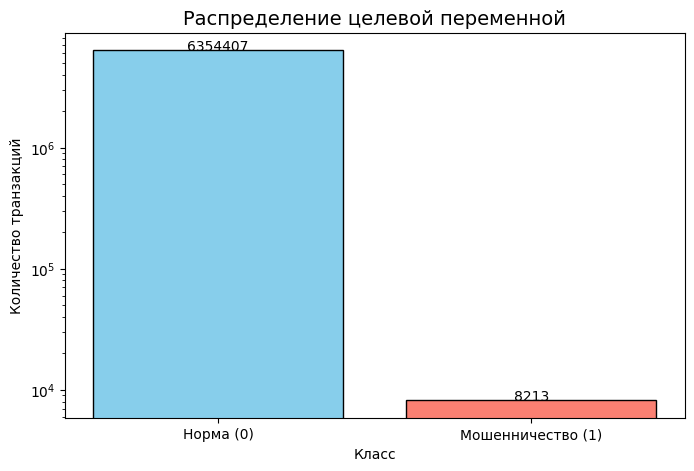

In [11]:
import matplotlib.pyplot as plt

fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(8,5))
colors = ['skyblue', 'salmon']
plt.bar(['Норма (0)', 'Мошенничество (1)'], fraud_counts.values, color=colors, edgecolor='black')
plt.title('Распределение целевой переменной', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Количество транзакций')
plt.yscale('log')
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.show()

Вывод: наблюдается сильный дисбаланс классов — мошенничество составляет лишь 0.13%. Это характерно для реальных платежных систем и требует применения техник балансировки (SMOTE, взвешивание классов).

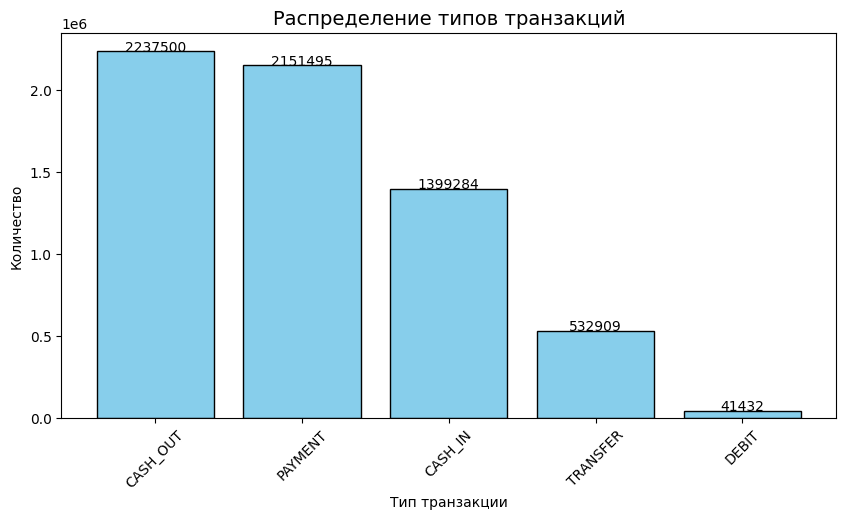

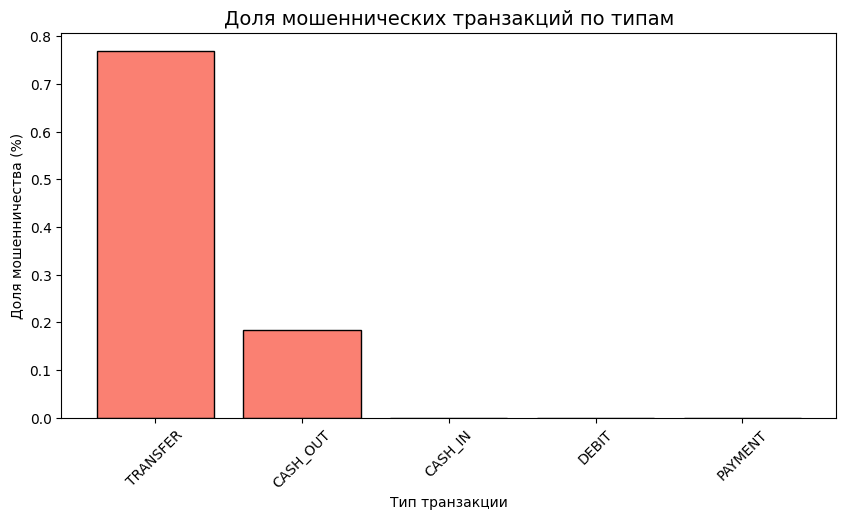

In [12]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(type_counts.index, type_counts.values, color='skyblue', edgecolor='black')
plt.title('Распределение типов транзакций', fontsize=14)
plt.xlabel('Тип транзакции')
plt.ylabel('Количество')
plt.xticks(rotation=45)
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 1000, str(v), ha='center', fontsize=10)
plt.show()

fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(fraud_by_type.index, fraud_by_type.values * 100, color='salmon', edgecolor='black')
plt.title('Доля мошеннических транзакций по типам', fontsize=14)
plt.xlabel('Тип транзакции')
plt.ylabel('Доля мошенничества (%)')
plt.xticks(rotation=45)
plt.show()

Вывод: Типы транзакций (payment, transfer, cash_out, debit, cash_in) распределены неравномерно (от 41432 до 2237500 записей). Это подтверждает сильный дисбаланс данных.

Мошенничество чаще всего происходит через TRANSFER и CASH_OUT. DEBIT, CASH_IN и PAYMENT практически не используются для мошенничества.

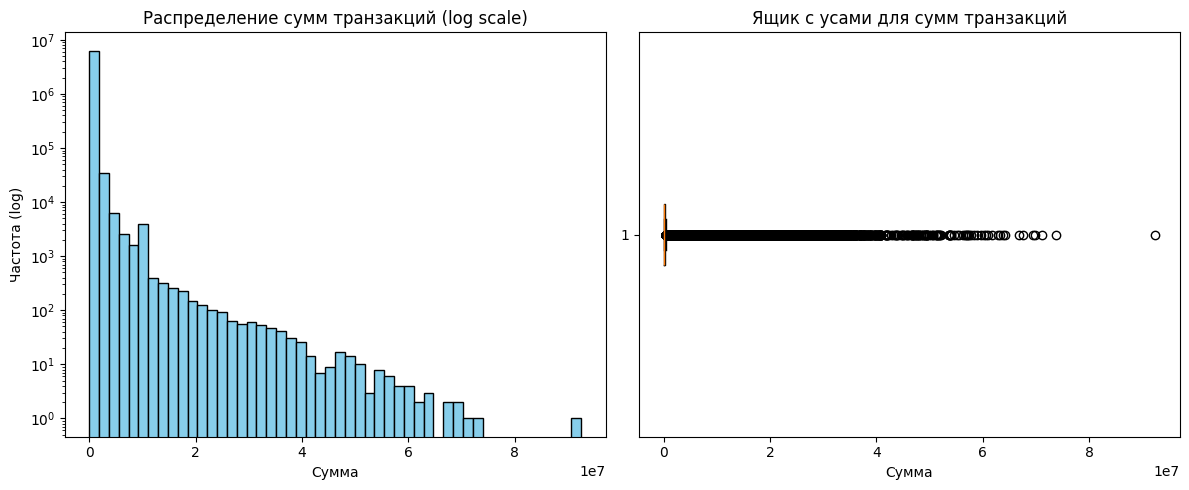


Статистика сумм для нормальных транзакций:
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

Статистика сумм для мошеннических транзакций:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


/tmp/ipykernel_24082/1431761694.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='isFraud', y='amount', palette=['skyblue', 'salmon'])


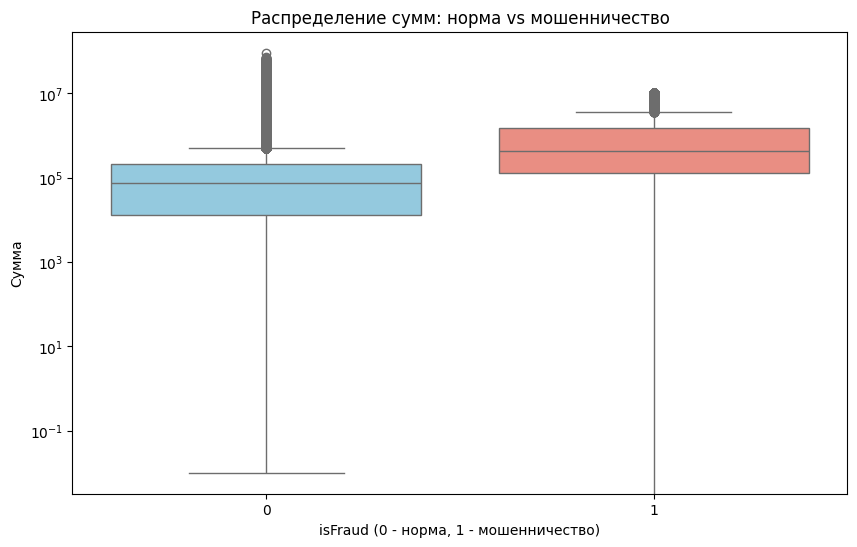

In [13]:
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['amount'], bins=50, color='skyblue', edgecolor='black', log=True)
plt.title('Распределение сумм транзакций (log scale)')
plt.xlabel('Сумма')
plt.ylabel('Частота (log)')

plt.subplot(1,2,2)
plt.boxplot(df['amount'], vert=False)
plt.title('Ящик с усами для сумм транзакций')
plt.xlabel('Сумма')

plt.tight_layout()
plt.show()

print(f'\nСтатистика сумм для нормальных транзакций:')
print(df[df['isFraud'] == 0]['amount'].describe())

print(f'\nСтатистика сумм для мошеннических транзакций:')
print(df[df['isFraud'] == 1]['amount'].describe())

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='isFraud', y='amount', palette=['skyblue', 'salmon'])
plt.title('Распределение сумм: норма vs мошенничество')
plt.xlabel('isFraud (0 - норма, 1 - мошенничество)')
plt.ylabel('Сумма')
plt.yscale('log')
plt.show()

Вывод: Мошеннические транзакции обычно имеют суммы больше обычных. Это важный признак для обнаружения аномалий.

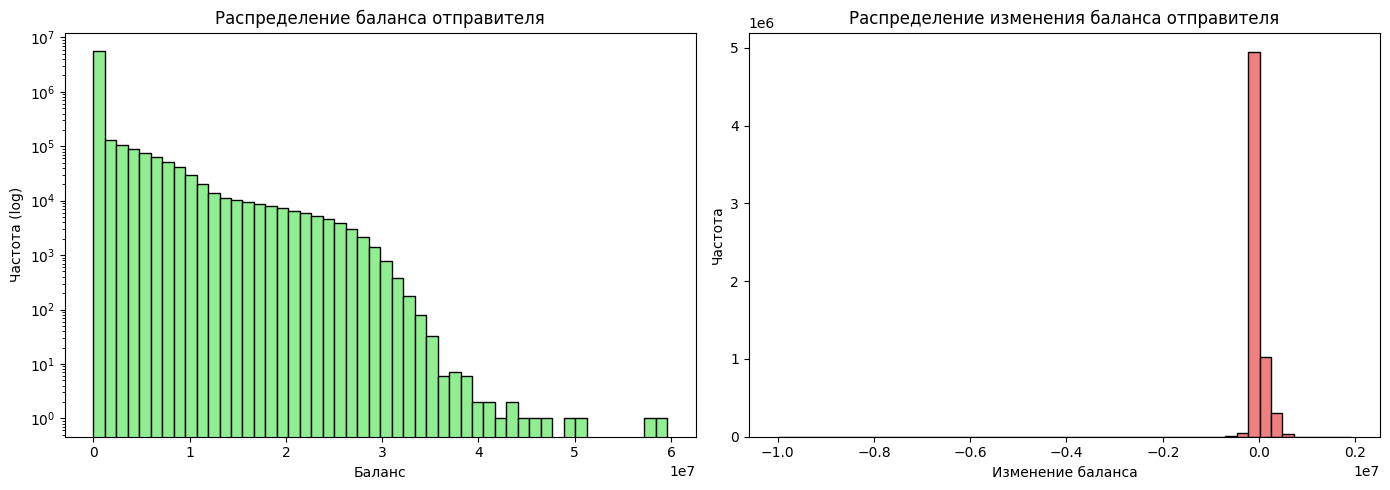

In [14]:
df['balance_change_org'] = df['newbalanceOrig'] - df['oldbalanceOrg']

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(df['oldbalanceOrg'], bins=50, color='lightgreen', edgecolor='black', log=True)
axes[0].set_title('Распределение баланса отправителя')
axes[0].set_xlabel('Баланс')
axes[0].set_ylabel('Частота (log)')

axes[1].hist(df['balance_change_org'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Распределение изменения баланса отправителя')
axes[1].set_xlabel('Изменение баланса')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Вывод: Большинство транзакций выполняется с ненулевым балансом. Мошеннические транзакции часто сопровождаются резким изменением баланса.

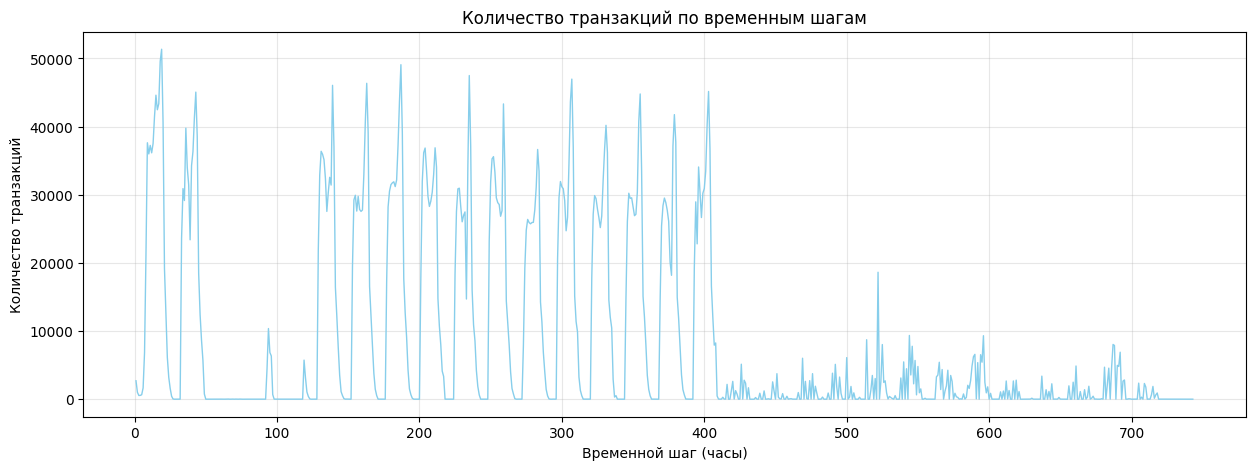


Шаги с максимальным количеством мошеннических транзакций:
step
212    40
523    30
501    28
387    28
249    28
425    28
730    28
160    26
398    26
694    24
dtype: int64


In [15]:
step_counts = df.groupby('step').size()

plt.figure(figsize=(15,5))
plt.plot(step_counts.index, step_counts.values, color='skyblue', linewidth=1)
plt.title('Количество транзакций по временным шагам')
plt.xlabel('Временной шаг (часы)')
plt.ylabel('Количество транзакций')
plt.grid(alpha=0.3)
plt.show()

fraud_by_step = df[df['isFraud'] == 1].groupby('step').size()
print(f'\nШаги с максимальным количеством мошеннических транзакций:')
print(fraud_by_step.sort_values(ascending=False).head(10))

Вывод: Интенсивность транзакций меняется со временем. Мошеннические операции часто приурочены к определенным временным окнам.

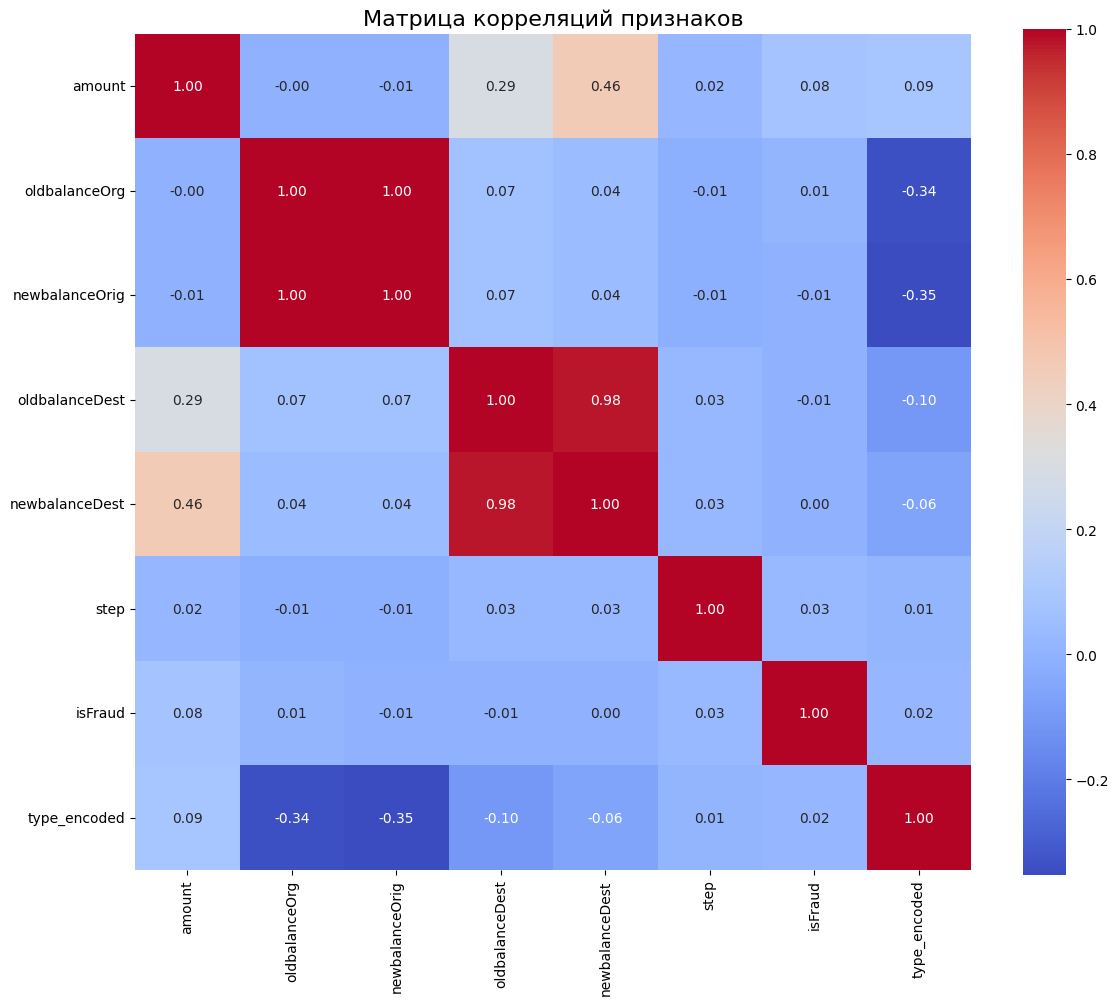


Корреляции признаков с isFraud (мошенничество):
isFraud           1.000000
amount            0.076688
step              0.031578
type_encoded      0.020833
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [16]:
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
            'newbalanceDest', 'step', 'isFraud']

df['type_encoded'] = df['type'].map({
    'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4
})
num_cols.append('type_encoded')

corr = df[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

print('\nКорреляции признаков с isFraud (мошенничество):')
corr_with_target = corr['isFraud'].sort_values(ascending=False)
print(corr_with_target)


Вывод: Корреляции признаков с целевой переменной очень слабые (максимальная — 0.076 у amount). Это означает отсутствие линейной зависимости между отдельными признаками и фактом мошенничества, что обосновывает необходимость использования нелинейных методов классификации (Random Forest, градиентный бустинг).

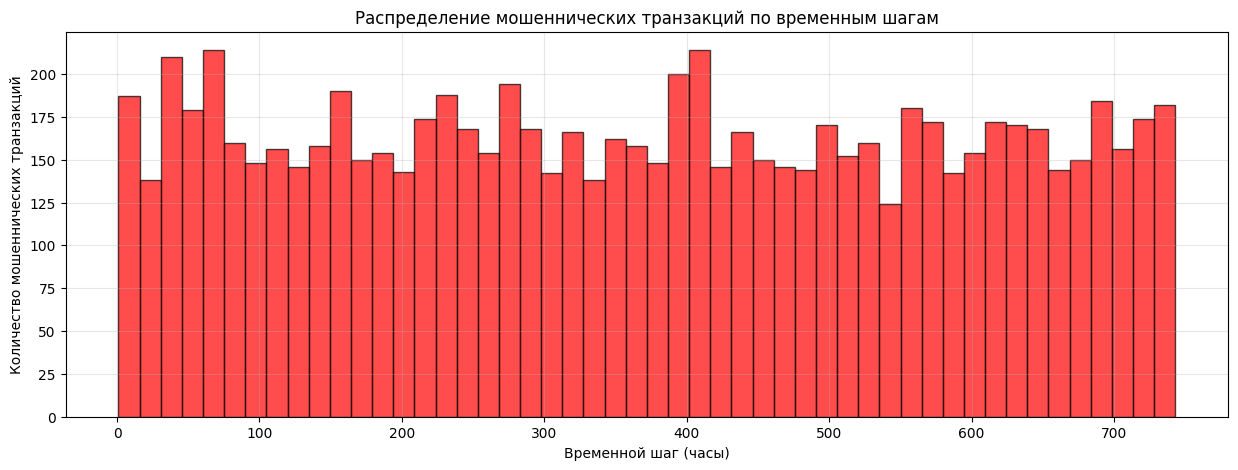

In [17]:
fraud_df = df[df['isFraud'] == 1]
normal_df = df[df['isFraud'] == 0]

plt.figure(figsize=(15,5))
plt.hist(fraud_df['step'], bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Распределение мошеннических транзакций по временным шагам')
plt.xlabel('Временной шаг (часы)')
plt.ylabel('Количество мошеннических транзакций')
plt.grid(alpha=0.3)
plt.show()

Вывод: Мошеннические транзакции распределены неравномерно по времени. Наблюдаются всплески активности в определенные периоды.

1. Дисбаланс классов:
   - Мошенничество составляет лишь 0.13% всех транзакций.
   - Требует применения SMOTE, взвешивания классов или других техник балансировки.
   - Метрики: PR-AUC предпочтительнее ROC-AUC.

2. Важные признаки:
   - amount (сумма) — мошеннические транзакции обычно крупнее.
   - oldbalanceOrg/newbalanceOrig — резкое изменение баланса — маркер мошенничества.
   - type — TRANSFER и CASH_OUT наиболее рискованны.
   - step — временная динамика важна.

3. Типы транзакций:
   - 5 типов: PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT.
   - Мошенничество практически отсутствует в CASH_IN, DEBIT, PAYMENT.

4. Масштаб данных:
   - 6+ миллионов транзакций.
   - Реальный дисбаланс — отличная задача для демонстрации работы с несбалансированными данными.

5. Для конвейера:
   - Признаки могут быть использованы без дополнительной обработки.
   - Рекомендуется создать балансовые признаки (разница old-new, отношение суммы к балансу).
   - Временные окна агрегации по step позволят вычислять частоту операций.

В ходе разведочного анализа данных установлено, что датасет не является синтетическим, что подтверждается сильным дисбалансом классов,
реалистичными распределениями сумм и корреляциями с типом транзакции.

Датасет пригоден для обучения моделей обнаружения мошенничества и отработки
методики построения NRT-конвейера.

Ключевые выводы для проектирования конвейера:

- Необходима обработка сильного дисбаланса (SMOTE, взвешенные метрики).
- Основные признаки: сумма, балансы, тип транзакции, время.
- Рекомендуемая метрика для оценки: PR-AUC.
- Данные могут быть использованы для демонстрации работы конвейера в реальных условиях.

***Заключение:*** EDA выполнен в полном объёме, все поставленные задачи решены. Полученные инсайты будут использованы при проектировании архитектуры конвейера,
выборе методов обнаружения мошенничества и настройке моделей.